In [1]:
import fsspec

In [4]:
fs, _ = fsspec.url_to_fs("/tmp")

In [5]:
fs.protocol

('file', 'local')

In [1]:
import tfrecord

/home/t-9dkarp/miniconda3/envs/autoi/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from tfrecord.torch.dataset import TFRecordDataset

In [5]:
dataset = TFRecordDataset("/mnt/labshare/SLIDES/CPTAC_downloads/HNSCC/tfrecords/256px_256um/C3L-02621-23.tfrecords", index_path="/mnt/labshare/SLIDES/CPTAC_downloads/HNSCC/tfrecords/256px_256um/C3L-02621-23.index.npz")

In [10]:
dataset[0]

NotImplementedError: 

In [1]:
from importlib import reload

import tqdm


import numpy as np

import matplotlib.pyplot as plt
import torch


from structured_eye.gigapath_uq.dinov2 import dataset
reload(dataset)


DESCRIPTOR = f"{dataset.DEFAULT_ROOT}:256px_256um:split=TRAIN:0.8"

/home/t-9dkarp/miniconda3/envs/seyesf/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 cuInit Failed, error CUDA_ERROR_NO_DEVICE
 cuFile initialization failed


In [6]:
count = 0
ds = dataset.make_dataset(DESCRIPTOR, max_shards=1, debug=True)
for img in ds:
    count += 1
display(count)

DEBUG: make_dataset: tfrecords_paths: len: 1
DEBUG: make_dataset: index_paths: len: 1


NotImplementedError: 

In [ ]:
%debug

> /home/t-9dkarp/miniconda3/envs/seyesf/lib/python3.9/site-packages/torch/utils/data/dataset.py(68)__getitem__()
     66 
     67     def __getitem__(self, index) -> T_co:
---> 68         raise NotImplementedError
     69 
     70     def __add__(self, other: 'Dataset[T_co]') -> 'ConcatDataset[T_co]':



ipdb>  up


> /home/t-9dkarp/miniconda3/envs/seyesf/lib/python3.9/site-packages/torch/utils/data/dataset.py(471)__getitem__()
    469         if isinstance(idx, list):
    470             return self.dataset[[self.indices[i] for i in idx]]
--> 471         return self.dataset[self.indices[idx]]
    472 
    473     def __len__(self):



ipdb>  up


> /tmp/ipykernel_3160919/3845428373.py(3)<module>()
      1 count = 0
      2 ds = dataset.make_dataset(DESCRIPTOR, max_shards=1, debug=True)
----> 3 for img in ds:
      4     count += 1
      5 display(count)



ipdb>  down


> /home/t-9dkarp/miniconda3/envs/seyesf/lib/python3.9/site-packages/torch/utils/data/dataset.py(471)__getitem__()
    469         if isinstance(idx, list):
    470             return self.dataset[[self.indices[i] for i in idx]]
--> 471         return self.dataset[self.indices[idx]]
    472 
    473     def __len__(self):



ipdb>  self.


*** SyntaxError: invalid syntax


ipdb>  self


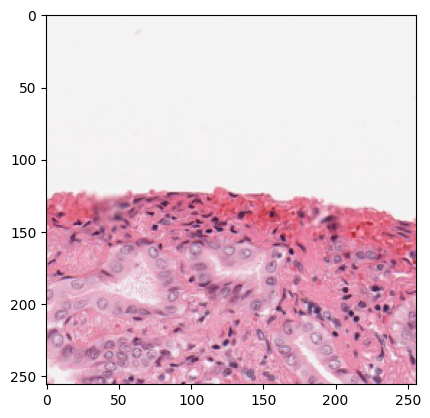

In [126]:
%matplotlib inline
plt.imshow(img)
plt.show()

In [98]:
%debug

> /home/t-9dkarp/slideflow/slideflow/tfrecord/reader.py(252)__init__()
    250         if self.index is not None and len(self.index) != 0:
    251             # For the case that there is only a single record in the file
--> 252             if len(self.index.shape) == 1:
    253                 self.index = np.expand_dims(self.index, axis=0)
    254 



ipdb>  up


> /home/t-9dkarp/slideflow/slideflow/tfrecord/reader.py(485)__init__()
    483             then all features contained in the file are extracted.
    484         """
--> 485         super().__init__(
    486             data_path,
    487             index,



ipdb>  up


> /home/t-9dkarp/slideflow/slideflow/tfrecord/reader.py(660)tfrecord_loader()
    658             compression_type=compression_type
    659         )
--> 660     return ExampleIterator(  # type: ignore
    661         data_path=data_path,
    662         index=index,



...

ipdb>  self.index.keys()


KeysView(<numpy.lib.npyio.NpzFile object at 0x14a299d2e730>)


ipdb>  list(self.index.keys())


*** Error in argument: '(self.index.keys())'


ipdb>  q


In [38]:
isinstance(ds, torch.utils.data.dataset.Dataset)

True

In [44]:
type(ds)

slideflow.tfrecord.torch.dataset.TFRecordDataset

In [1]:
import os
from datablocks import export, expand_strings

In [2]:
export("""
export SEYE="${HOME}/seye"
        export DATALAKE="/mnt/labshare/PANCAN-GIGAPATH"
        export REVISION="gigapath/pancan/v1"
""")

In [3]:
os.environ['SEYE']

'/home/t-9dkarp/seye'

In [4]:
s = """DBX('seye.gigapath.IMGS', 'CPIMGS', repo="${SEYE}", revision='${REVISION}').SCOPE(slides=DBX.Path('/mnt/labshare/SLIDES/CPTAC_downloads'), origin='CPTAC', tile_px=256, tile_um=256)"""

In [5]:
expand_strings(s)

'DBX(\'seye.gigapath.IMGS\', \'CPIMGS\', repo="/home/t-9dkarp/seye"gigapath/pancan/v1\'${REVISION}\').SCOPE(slides=DBX.Path(\'/mnt/labshare/SLIDES/CPTAC_downloads\'), origin=\'CPTAC\', tile_px=256, tile_um=256)'

In [4]:
e = """
export SEYE="${HOME}/seye"
        export DATALAKE="/mnt/labshare/PANCAN-GIGAPATH"
        export REVISION="gigapath/pancan/v1"
"""

In [7]:
import re
r = re.compile("""\$\{[^\{\}\$]*\}""")

In [8]:
m = list(r.finditer(s))

In [9]:
len(m)

2

In [10]:
m[0]

<re.Match object; span=(42, 49), match='${SEYE}'>

In [11]:
m[1]

<re.Match object; span=(62, 73), match='${REVISION}'>